# WEEK 3 : EXPLORATORY ANALYSIS - UNIVARIATE AND BIVARIATE ANALYSIS

Import Libraries

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"]=(10,6)

Load Data

In [62]:
df = pd.read_csv("../data/processed/week2_processed.csv")

print(df.shape)
df.head()

(98619, 32)


,Passenger_ID,First_Name,Last_Name,Passenger_Full_Name,Gender,Age,Age_Group,Nationality,Airport_Name,Airport_Country_Code,...,Weekly_Traffic,Arrival_Airport,Pilot_Name,Pilot_Workload,Flight_Status,Is_Flight_Delayed,Delay_Cause,Delay_Severity,Operational_Risk,Flight_Type
0,ABVWIg,Edithe,Leggis,Edithe Leggis,Female,62,Senior Citizen,Japan,Coldfoot Airport,US,...,8386.0,CXF,Fransisco Hazeldine,1,On Time,0,No Delay,No Impact,Low Risk,International
1,jkXXAX,Elwood,Catt,Elwood Catt,Male,62,Senior Citizen,Nicaragua,Kugluktuk Airport,CA,...,8758.0,YCO,Marla Parsonage,1,On Time,0,No Delay,No Impact,Low Risk,International
2,CdUz2g,Darby,Felgate,Darby Felgate,Male,67,Senior Citizen,Russia,Grenoble-Isère Airport,FR,...,8386.0,GNB,Rhonda Amber,1,On Time,0,No Delay,No Impact,Low Risk,International
3,BRS38V,Dominica,Pyle,Dominica Pyle,Female,71,Senior Citizen,China,Ottawa / Gatineau Airport,CA,...,8462.0,YND,Kacie Commucci,1,Delayed,1,Operational / Technical,Operational Impact,Medium Risk,International
4,9kvTLo,Bay,Pencost,Bay Pencost,Male,21,Youth,China,Gillespie Field,US,...,8462.0,SEE,Ebonee Tree,1,On Time,0,No Delay,No Impact,Low Risk,International


Data Structure 

In [63]:
df.info()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98619 entries, 0 to 98618
Data columns (total 32 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Passenger_ID          98619 non-null  object 
 1   First_Name            98619 non-null  object 
 2   Last_Name             98619 non-null  object 
 3   Passenger_Full_Name   98619 non-null  object 
 4   Gender                98619 non-null  object 
 5   Age                   98619 non-null  int64  
 6   Age_Group             98619 non-null  object 
 7   Nationality           98619 non-null  object 
 8   Airport_Name          98619 non-null  object 
 9   Airport_Country_Code  98619 non-null  object 
 10  Country_Name          98619 non-null  object 
 11  Airport_Continent     98619 non-null  object 
 12  Continents            98619 non-null  object 
 13  Airport_Location      98619 non-null  object 
 14  Airport_Congestion    98619 non-null  int64  
 15  Departure_Date     

,Passenger_ID,First_Name,Last_Name,Passenger_Full_Name,Gender,Age,Age_Group,Nationality,Airport_Name,Airport_Country_Code,...,Weekly_Traffic,Arrival_Airport,Pilot_Name,Pilot_Workload,Flight_Status,Is_Flight_Delayed,Delay_Cause,Delay_Severity,Operational_Risk,Flight_Type
count,98619,98619,98619,98619,98619,98619.000000,98619,98619,98619,98619,...,59658.000000,98619,98619,98619.000000,98619,98619.00000,98619,98619,98619,98619
unique,98619,8437,41658,98610,2,NaN,5,240,9062,235,...,NaN,9024,98605,NaN,3,NaN,3,2,3,2
top,8JYEcz,Gale,Dyball,Auberon Alennikov,Male,NaN,Senior Citizen,China,San Pedro Airport,US,...,NaN,0,Valeda Pratty,NaN,Cancelled,NaN,Weather / Climatic,Operational Impact,High Risk,International
freq,1,37,17,2,49598,NaN,38376,18317,43,22104,...,NaN,873,2,NaN,32942,NaN,32942,65773,32942,96844
mean,NaN,NaN,NaN,NaN,NaN,45.504021,NaN,NaN,NaN,NaN,...,8532.060445,NaN,NaN,1.000284,NaN,0.66694,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,25.929849,NaN,NaN,NaN,NaN,...,279.301585,NaN,NaN,0.016848,NaN,0.47131,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,...,7928.000000,NaN,NaN,1.000000,NaN,0.00000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,23.000000,NaN,NaN,NaN,NaN,...,8386.000000,NaN,NaN,1.000000,NaN,0.00000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,46.000000,NaN,NaN,NaN,NaN,...,8563.000000,NaN,NaN,1.000000,NaN,1.00000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,68.000000,NaN,NaN,NaN,NaN,...,8772.000000,NaN,NaN,1.000000,NaN,1.00000,NaN,NaN,NaN,NaN


Temporal Dataset

In [64]:
df_time = df.dropna(
subset=["Month_Name",
        "Departure_DayOfWeek"])

Creating Label Function

In [65]:
def add_labels(ax,total=None):
    for p in ax.patches:
        value=p.get_height()
        if total:
            label=f"{int(value)} ({value/total*100:.1f}%)"
        else:
            label=f"{int(value)}"

        ax.annotate(
            label,
            (p.get_x()+p.get_width()/2,value),
            ha="center"
        )

PASSANGER'S AGE ANALYSIS

Age Distribition

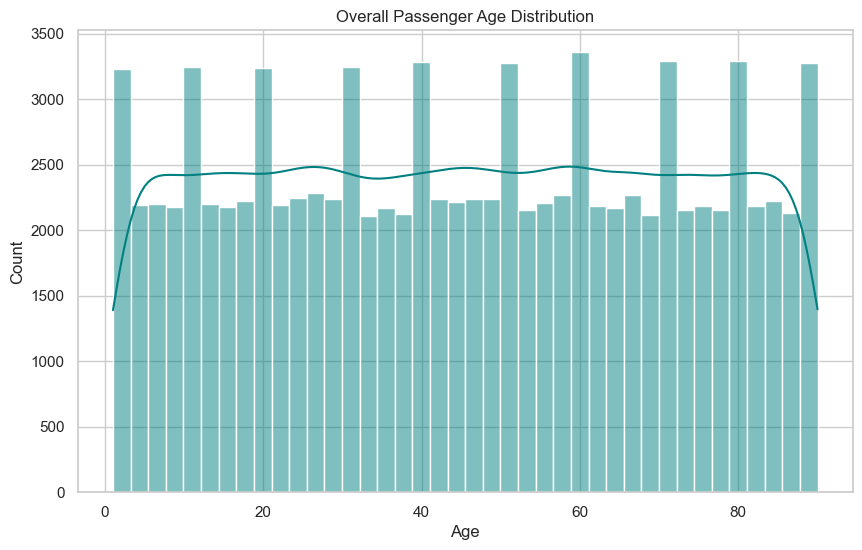

In [66]:
sns.histplot(
df["Age"],
bins=40,
kde=True,
color="teal")

plt.title("Overall Passenger Age Distribution")
plt.show()


Age Group Distribution

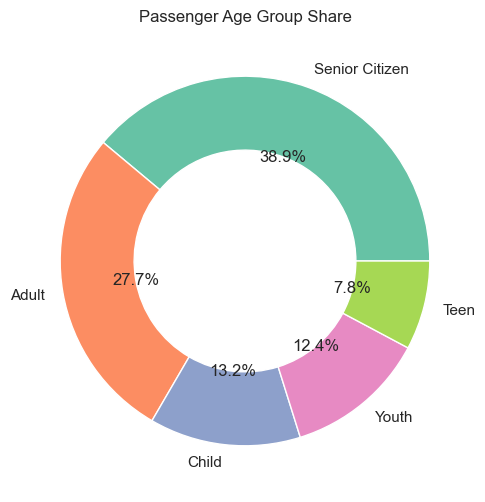

In [67]:
age_counts=df["Age_Group"].value_counts()

plt.pie(
age_counts,
labels=age_counts.index,
autopct="%1.1f%%",
colors=sns.color_palette("Set2"),
wedgeprops={"width":0.4})

plt.title("Passenger Age Group Share")
plt.show()

PASSENGER DEMOGRAPHICS

Gender Distribution

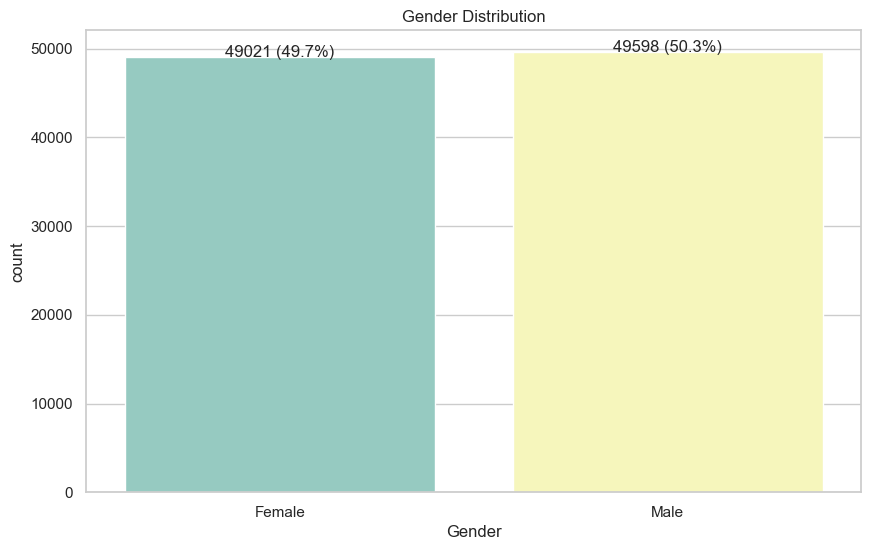

In [68]:
ax=sns.countplot(
x="Gender",
data=df,
palette="Set3",
hue='Gender',
legend=False)

plt.title("Gender Distribution")
add_labels(ax,len(df))
plt.show()

Nationality Distribution

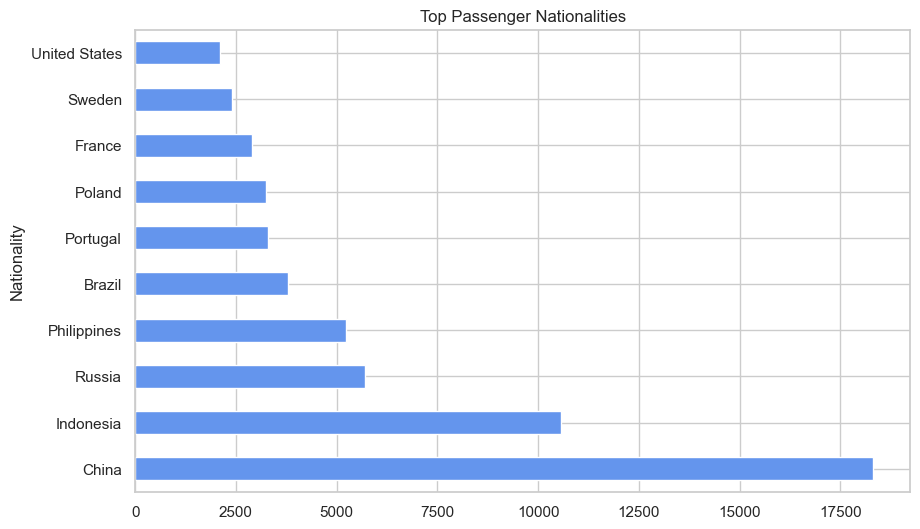

In [69]:
top_nat=df["Nationality"].value_counts().head(10)

top_nat.plot(
kind="barh",
color="cornflowerblue")

plt.title("Top Passenger Nationalities")
plt.show()

AIRPORT & TRAFFIC ANALYSIS

Busiest Airports

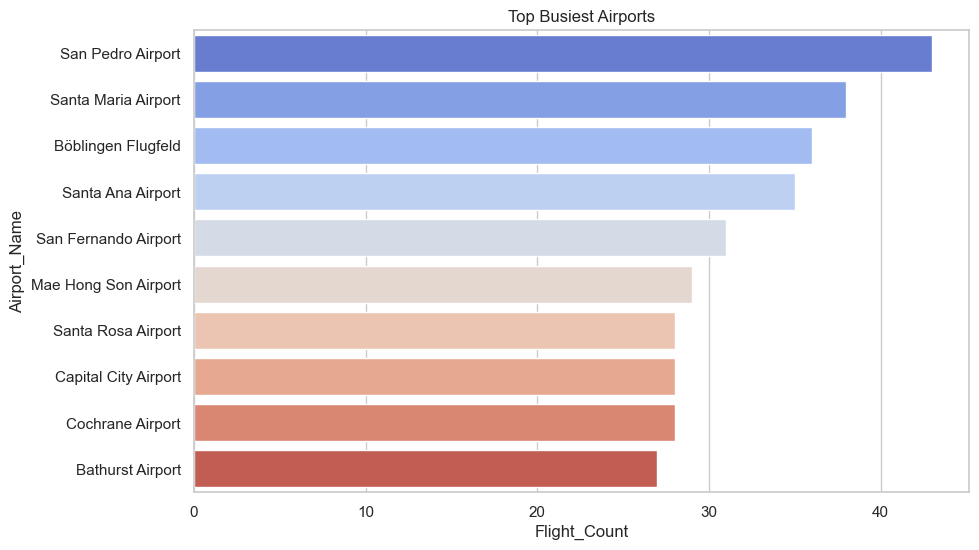

In [70]:
top_airports = (
    df["Airport_Name"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_airports.columns = ["Airport_Name", "Flight_Count"]

sns.barplot(
    data=top_airports,
    x="Flight_Count",
    y="Airport_Name",
    hue="Airport_Name",
    palette="coolwarm",
    legend=False
)

plt.title("Top Busiest Airports")
plt.show()

Traffic Share by Continent

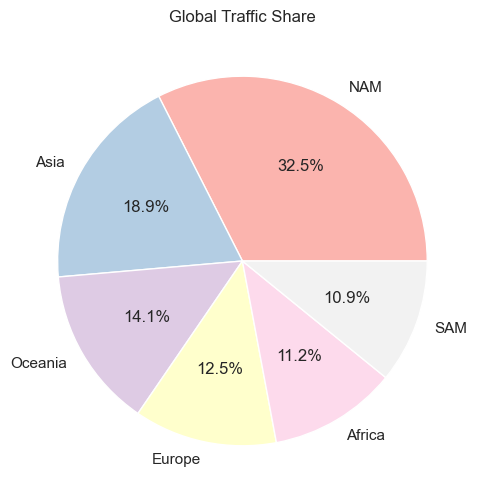

In [71]:
df["Airport_Continent"].value_counts().plot(
kind="pie",
autopct="%1.1f%%",
colormap="Pastel1")

plt.title("Global Traffic Share")
plt.ylabel("")
plt.show()

ENGINEERED FEATURE ANALYSIS

Airport Congestion Distribution

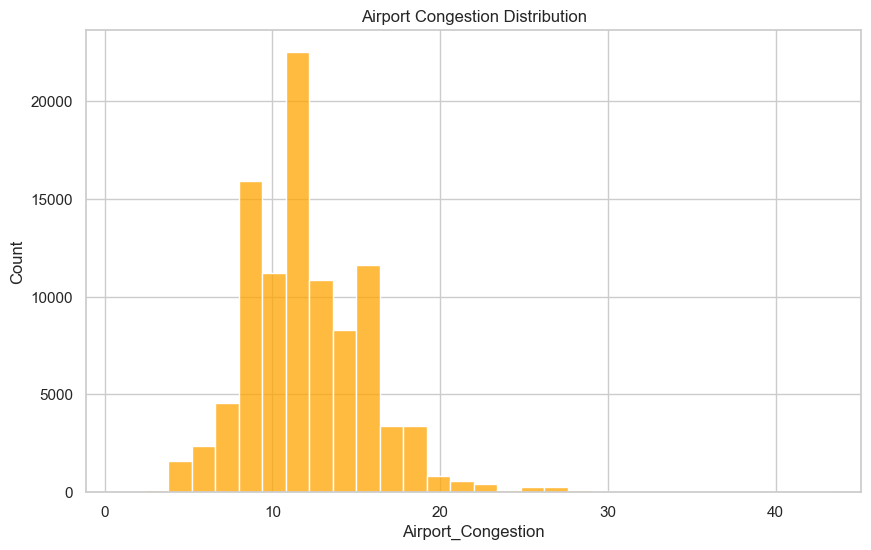

In [72]:
sns.histplot(
df["Airport_Congestion"],
bins=30,
color="orange")

plt.title("Airport Congestion Distribution")
plt.show()

FLIGHT STATUS

Domestic VS International

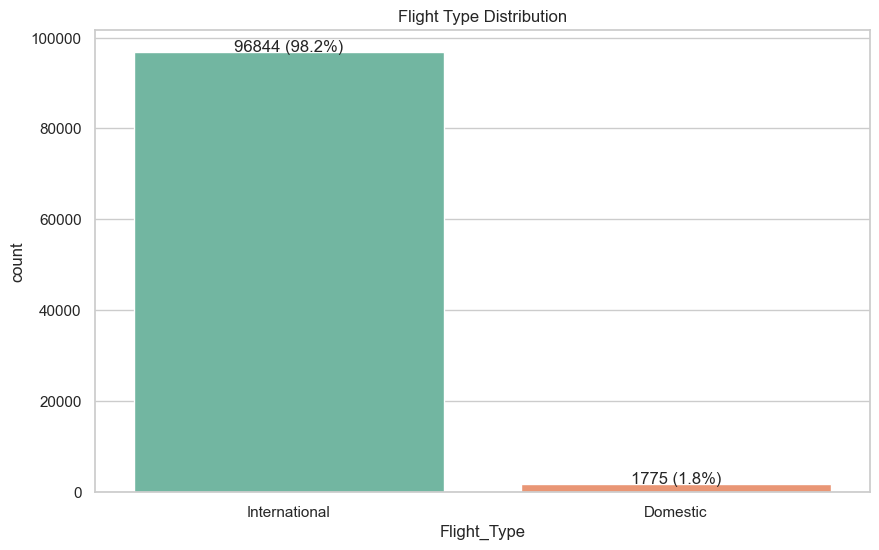

In [73]:
ax=sns.countplot(
x="Flight_Type",
data=df,
palette="Set2",
hue='Flight_Type',
legend=False)

plt.title("Flight Type Distribution")
add_labels(ax,len(df))
plt.show()

Traffic Load Comparison

<Axes: xlabel='Flight_Type', ylabel='Monthly_Traffic'>

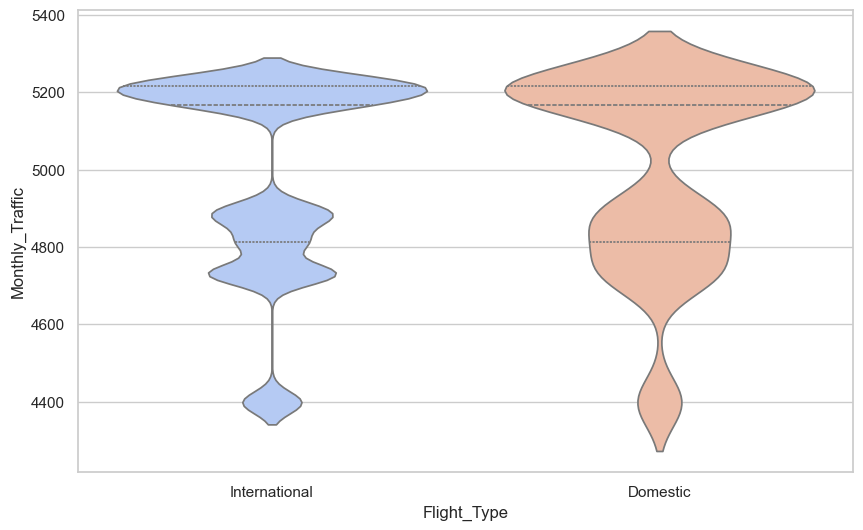

In [74]:
sns.violinplot(
    x="Flight_Type",
    y="Monthly_Traffic",
    data=df,
    palette="coolwarm",
    hue='Flight_Type',
    legend=False,
    inner="quartile"
)

TEMPORAL TRAFFIC

Monthly Flights

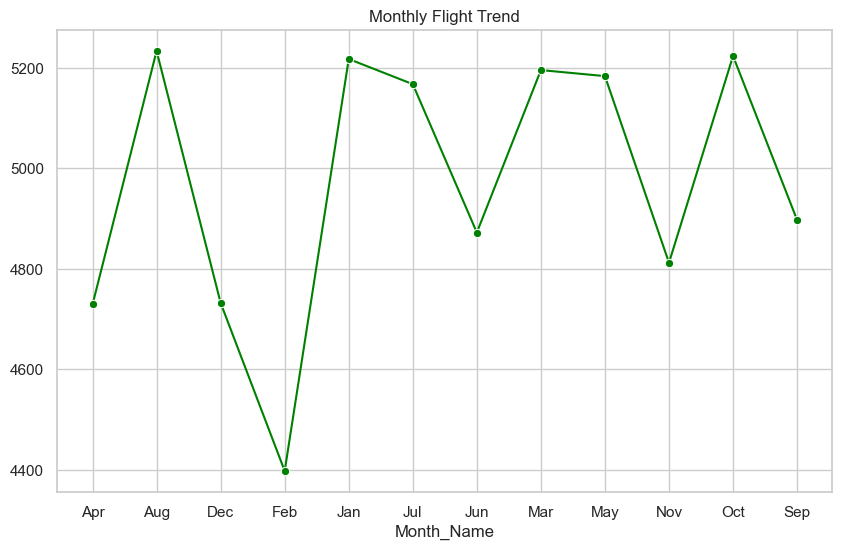

In [75]:
month_counts=df_time["Month_Name"].value_counts().sort_index()

sns.lineplot(
x=month_counts.index,
y=month_counts.values,
marker="o",
color="green")

plt.title("Monthly Flight Trend")
plt.show()

Weekly Flights

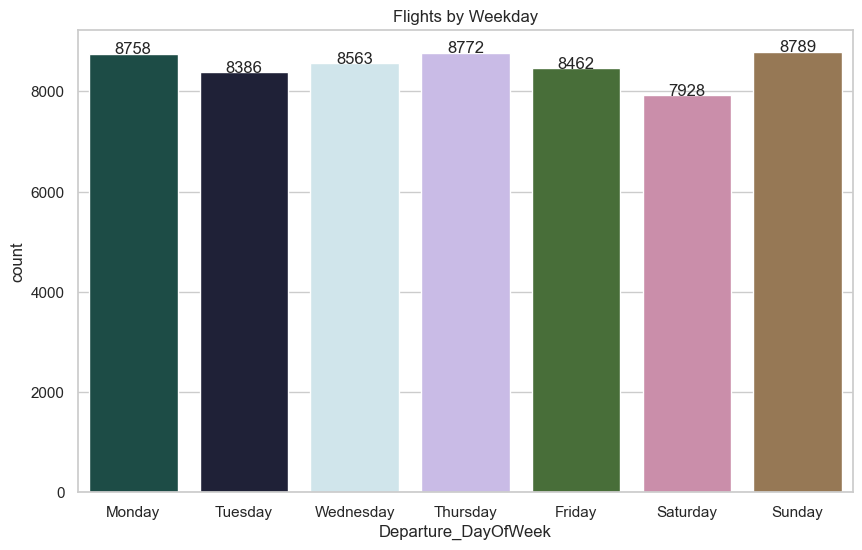

In [76]:
weekday_order = [
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"
]

ax = sns.countplot(
    x="Departure_DayOfWeek",
    data=df_time,
    order=weekday_order,
    palette="cubehelix",
    hue="Departure_DayOfWeek",
    legend=False
)

plt.title("Flights by Weekday")

add_labels(ax)

plt.show()

### Week 3 Insights

- Passenger demand dominated by working-age travellers. 
- Hub airports experience high congestion.
- International operations show heavier traffic loads.
- Traffic demand varies seasonally.